In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt


Accuracy: 0.9814969617078738
              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95     12004
     Anomaly       0.99      0.99      0.99     50202

    accuracy                           0.98     62206
   macro avg       0.97      0.97      0.97     62206
weighted avg       0.98      0.98      0.98     62206



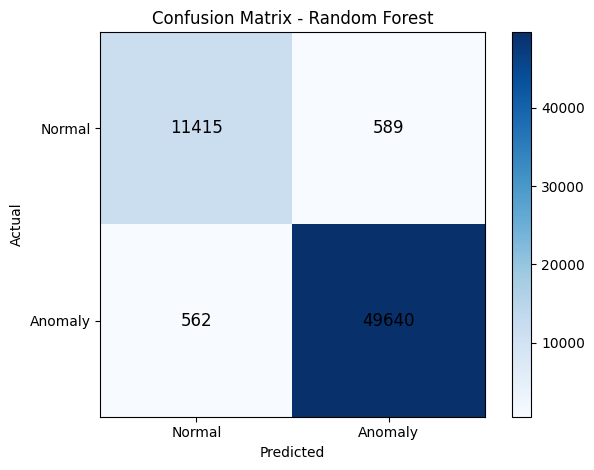

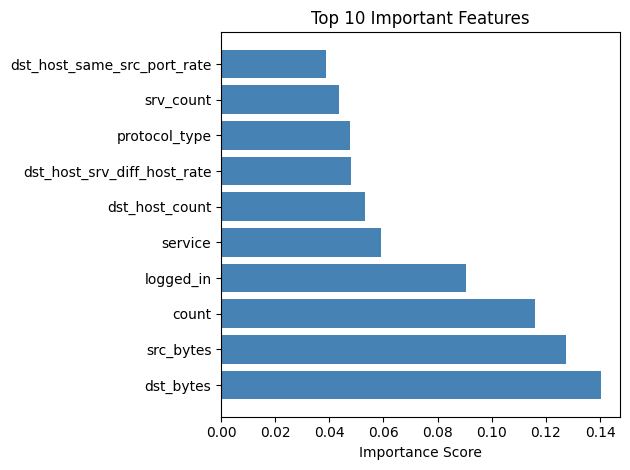

In [2]:
# ── 1. Load Data ──────────────────────────────────────────────
cols = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label"
]
df = pd.read_csv("corrected.gz", names=cols)

# ── 2. Preprocessing (Alternative Methods) ─────────────────────

# Method 1: Using pd.Categorical instead of LabelEncoder
df['protocol_type'] = pd.Categorical(df['protocol_type']).codes
df['service'] = pd.Categorical(df['service']).codes
df['flag'] = pd.Categorical(df['flag']).codes

# Create binary label
df['binary_label'] = df['label'].apply(lambda x: 0 if x == 'normal.' else 1)

X = df.drop(['label', 'binary_label'], axis=1)
y = df['binary_label']

# Method 2: Manual Z-Score Scaling (instead of StandardScaler)
def z_score_scale(X):
    return (X - X.mean()) / X.std()

X_scaled = z_score_scale(X)

# ── 3. Train/Test Split ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ── 4. Train Random Forest ────────────────────────────────────
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ── 5. Evaluate ───────────────────────────────────────────────
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Normal", "Anomaly"]))

# ── 6. Confusion Matrix Plot ──────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
labels = ["Normal", "Anomaly"]

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i][j]), ha='center', va='center', 
                color='black', fontsize=12)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

# ── 7. Feature Importance Plot ────────────────────────────────
feature_names = df.drop(['label', 'binary_label'], axis=1).columns
importances = pd.Series(model.feature_importances_, index=feature_names)
top10 = importances.nlargest(10)

plt.figure()
plt.barh(top10.index, top10.values, color='steelblue')
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

        OUTPUT 1: MODEL PERFORMANCE METRICS

✅ Accuracy Score: 98.15%

Classification Report:
-------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95     12004
     Anomaly       0.99      0.99      0.99     50202

    accuracy                           0.98     62206
   macro avg       0.97      0.97      0.97     62206
weighted avg       0.98      0.98      0.98     62206

⚠️  Anomaly Recall: 98.88%
    → Your system caught 98.88% of ALL real attacks!

        OUTPUT 2: CONFUSION MATRIX

✅ True Negatives  (TN) - Normal correctly identified : 11415
✅ True Positives  (TP) - Attacks correctly caught     : 49640
⚠️  False Positives (FP) - Normal flagged as attack    : 589
🚨 False Negatives (FN) - Attacks that slipped through : 562


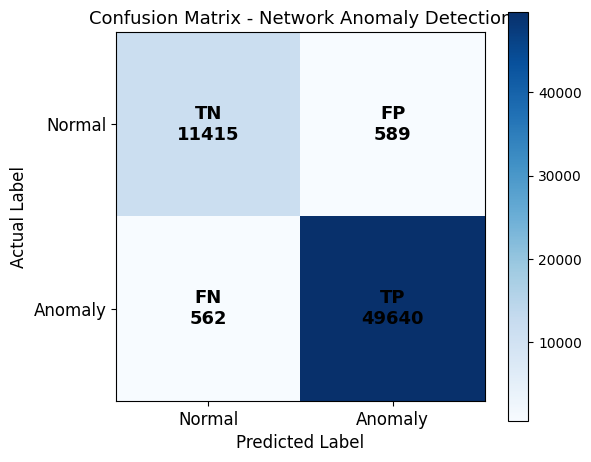

✅ Confusion Matrix saved as confusion_matrix.png

        OUTPUT 3: FEATURE IMPORTANCE RANKING

Top 10 Most Important Features:
----------------------------------------
 1. dst_bytes                           → 0.1404
 2. src_bytes                           → 0.1273
 3. count                               → 0.1159
 4. logged_in                           → 0.0905
 5. service                             → 0.0591
 6. dst_host_count                      → 0.0531
 7. dst_host_srv_diff_host_rate         → 0.0480
 8. protocol_type                       → 0.0477
 9. srv_count                           → 0.0434
10. dst_host_same_src_port_rate         → 0.0389


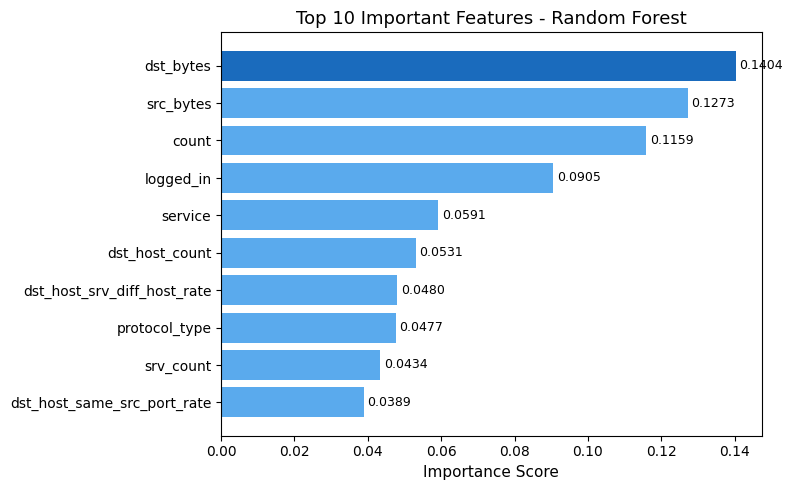

✅ Feature Importance chart saved as feature_importance.png

        OUTPUT 4: SAMPLE PREDICTION TABLE

  Sample No. Actual Label Predicted Label    Result
          1      Anomaly         Anomaly ✅ Correct
          2      Anomaly         Anomaly ✅ Correct
          3      Anomaly         Anomaly ✅ Correct
          4       Normal          Normal ✅ Correct
          5      Anomaly         Anomaly ✅ Correct
          6       Normal          Normal ✅ Correct
          7       Normal          Normal ✅ Correct
          8      Anomaly         Anomaly ✅ Correct
          9       Normal          Normal ✅ Correct
         10      Anomaly         Anomaly ✅ Correct

📊 Summary:
   Correct Predictions : 10/10
   Wrong Predictions   : 0/10


In [ ]:
# ── 1. Load Data ──────────────────────────────────────────────
cols = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label"
]
df = pd.read_csv("corrected.gz", names=cols)

# ── 2. Preprocessing ──────────────────────────────────────────
df['binary_label'] = df['label'].apply(lambda x: 0 if x == 'normal.' else 1)

df['protocol_type'] = pd.Categorical(df['protocol_type']).codes
df['service']       = pd.Categorical(df['service']).codes
df['flag']          = pd.Categorical(df['flag']).codes

X = df.drop(['label', 'binary_label'], axis=1)
y = df['binary_label']

X_scaled = (X - X.mean()) / X.std()

# ── 3. Train/Test Split ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ── 4. Train Model ────────────────────────────────────────────
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ════════════════════════════════════════════════════════════════
# OUTPUT 1: Model Performance Metrics
# ════════════════════════════════════════════════════════════════
print("=" * 55)
print("        OUTPUT 1: MODEL PERFORMANCE METRICS")
print("=" * 55)

acc = accuracy_score(y_test, y_pred)
print(f"\n Accuracy Score: {acc * 100:.2f}%\n")
print("Classification Report:")
print("-" * 55)
print(classification_report(y_test, y_pred, target_names=["Normal", "Anomaly"]))

# Highlight Anomaly Recall
report = classification_report(y_test, y_pred,
         target_names=["Normal", "Anomaly"], output_dict=True)
anomaly_recall = report['Anomaly']['recall'] * 100
print(f"  Anomaly Recall: {anomaly_recall:.2f}%")
print(f"    → Your system caught {anomaly_recall:.2f}% of ALL real attacks!")
print("=" * 55)

# ════════════════════════════════════════════════════════════════
# OUTPUT 2: Confusion Matrix
# ════════════════════════════════════════════════════════════════
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print("\n" + "=" * 55)
print("        OUTPUT 2: CONFUSION MATRIX")
print("=" * 55)
print(f"\n True Negatives  (TN) - Normal correctly identified : {TN}")
print(f" True Positives  (TP) - Attacks correctly caught     : {TP}")
print(f"  False Positives (FP) - Normal flagged as attack    : {FP}")
print(f" False Negatives (FN) - Attacks that slipped through : {FN}")
print("=" * 55)

labels = ["Normal", "Anomaly"]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticklabels(labels, fontsize=12)

# Add TN, FP, FN, TP labels inside boxes
box_labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{box_labels[i][j]}\n{cm[i][j]}",
                ha='center', va='center', fontsize=13,
                color='black', fontweight='bold')

ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("Actual Label", fontsize=12)
ax.set_title("Confusion Matrix - Network Anomaly Detection", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

# ════════════════════════════════════════════════════════════════
# OUTPUT 3: Feature Importance Ranking
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("        OUTPUT 3: FEATURE IMPORTANCE RANKING")
print("=" * 55)

feature_names = X.columns
importances = pd.Series(model.feature_importances_, index=feature_names)
top10 = importances.nlargest(10).sort_values()

print("\nTop 10 Most Important Features:")
print("-" * 40)
for rank, (feat, score) in enumerate(top10.sort_values(ascending=False).items(), 1):
    print(f"{rank:2}. {feat:35} → {score:.4f}")
print("=" * 55)

plt.figure(figsize=(8, 5))
colors = ['#1a6bbd' if i == len(top10)-1 else '#5aaaed' for i in range(len(top10))]
plt.barh(top10.index, top10.values, color=colors)
plt.title("Top 10 Important Features - Random Forest", fontsize=13)
plt.xlabel("Importance Score", fontsize=11)

for i, (val, name) in enumerate(zip(top10.values, top10.index)):
    plt.text(val + 0.001, i, f"{val:.4f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()
# print(" Feature Importance chart saved as feature_importance.png")

# ════════════════════════════════════════════════════════════════
# OUTPUT 4: Sample Prediction Table
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("        OUTPUT 4: SAMPLE PREDICTION TABLE")
print("=" * 55)

sample = pd.DataFrame({
    'Sample No.'      : range(1, 11),
    'Actual Label'    : ['Normal' if v == 0 else 'Anomaly' for v in y_test[:10]],
    'Predicted Label' : ['Normal' if v == 0 else 'Anomaly' for v in y_pred[:10]],
})
sample['Result'] = sample.apply(
    lambda row: ' Correct' if row['Actual Label'] == row['Predicted Label']
                else ' Wrong', axis=1
)

print("\n", sample.to_string(index=False))
print("\n Summary:")
correct = (sample['Result'] == ' Correct').sum()
print(f"   Correct Predictions : {correct}/10")
print(f"   Wrong Predictions   : {10 - correct}/10")
print("=" * 55)